# Task 5: Exploratory Data Analysis (EDA) - Titanic Dataset

## Objective
To explore the Titanic dataset using statistical analysis and visualization to identify patterns, relationships, trends, and anomalies.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [20]:
df = pd.read_csv("/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [24]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [25]:
print("Gender:")
print(df["Sex"].value_counts())

print("\nPassenger Class:")
print(df["Pclass"].value_counts())

print("\nSurvival:")
print(df["Survived"].value_counts())

Gender:
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Survival:
Survived
0    549
1    342
Name: count, dtype: int64


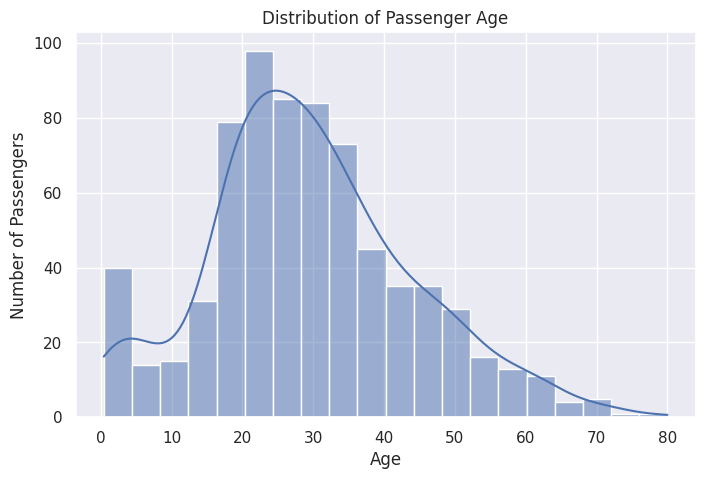

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"].dropna(), bins=20, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

### Observation
The histogram shows the distribution of passenger ages. Most passengers were young or middle-aged, while relatively fewer passengers were elderly.

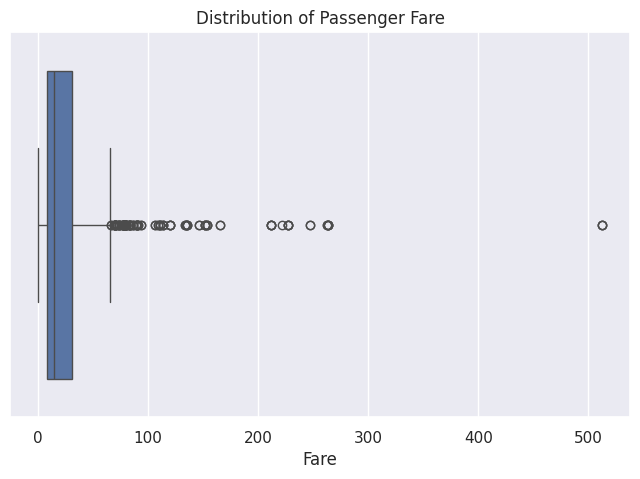

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.show()

### Observation
The boxplot shows that most passengers paid relatively lower fares. A few passengers paid very high fares, indicating the presence of outliers.

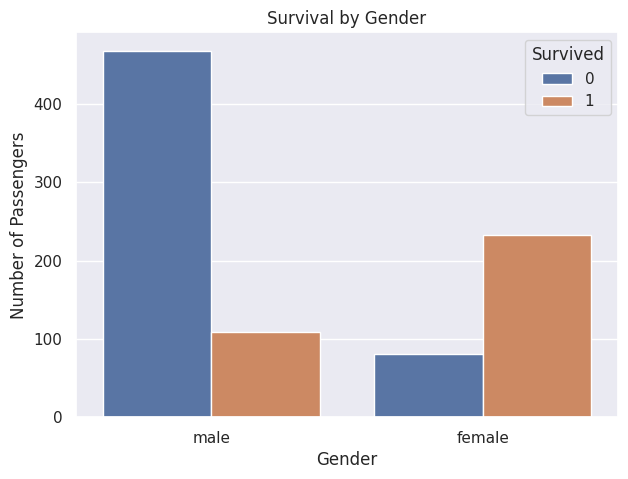

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

### Observation
The graph shows a clear difference in survival between genders. Female passengers had a higher proportion of survivors compared with male passengers.

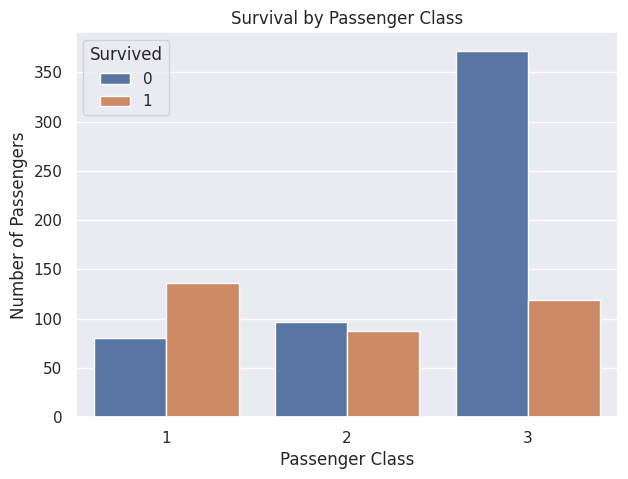

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

### Observation
The graph shows that passengers in higher classes generally had better survival outcomes than passengers in lower classes.

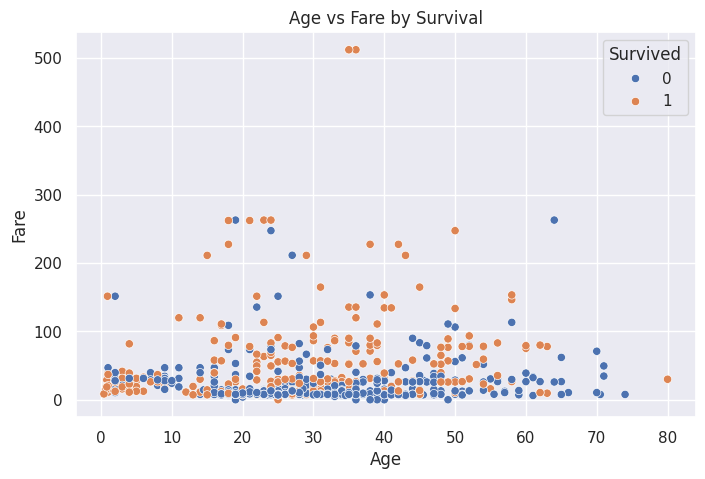

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

### Observation
The scatterplot shows the relationship between passenger age and fare. There is considerable variation in fare values, while some passengers paid substantially higher fares than others.

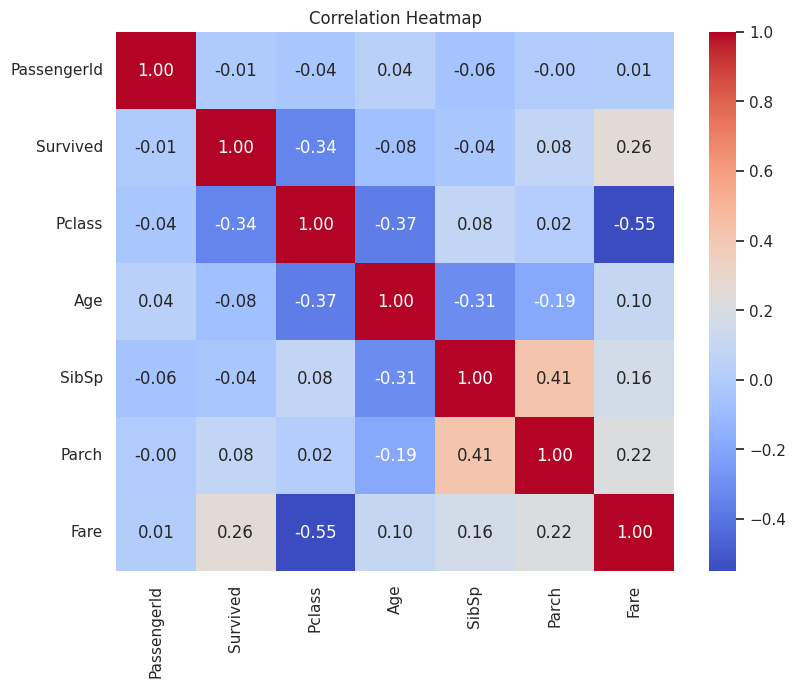

In [32]:
plt.figure(figsize=(9,7))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Observation
The heatmap shows the correlation between numerical variables. Passenger class and fare show a noticeable relationship, while survival also has relationships with some passenger characteristics.

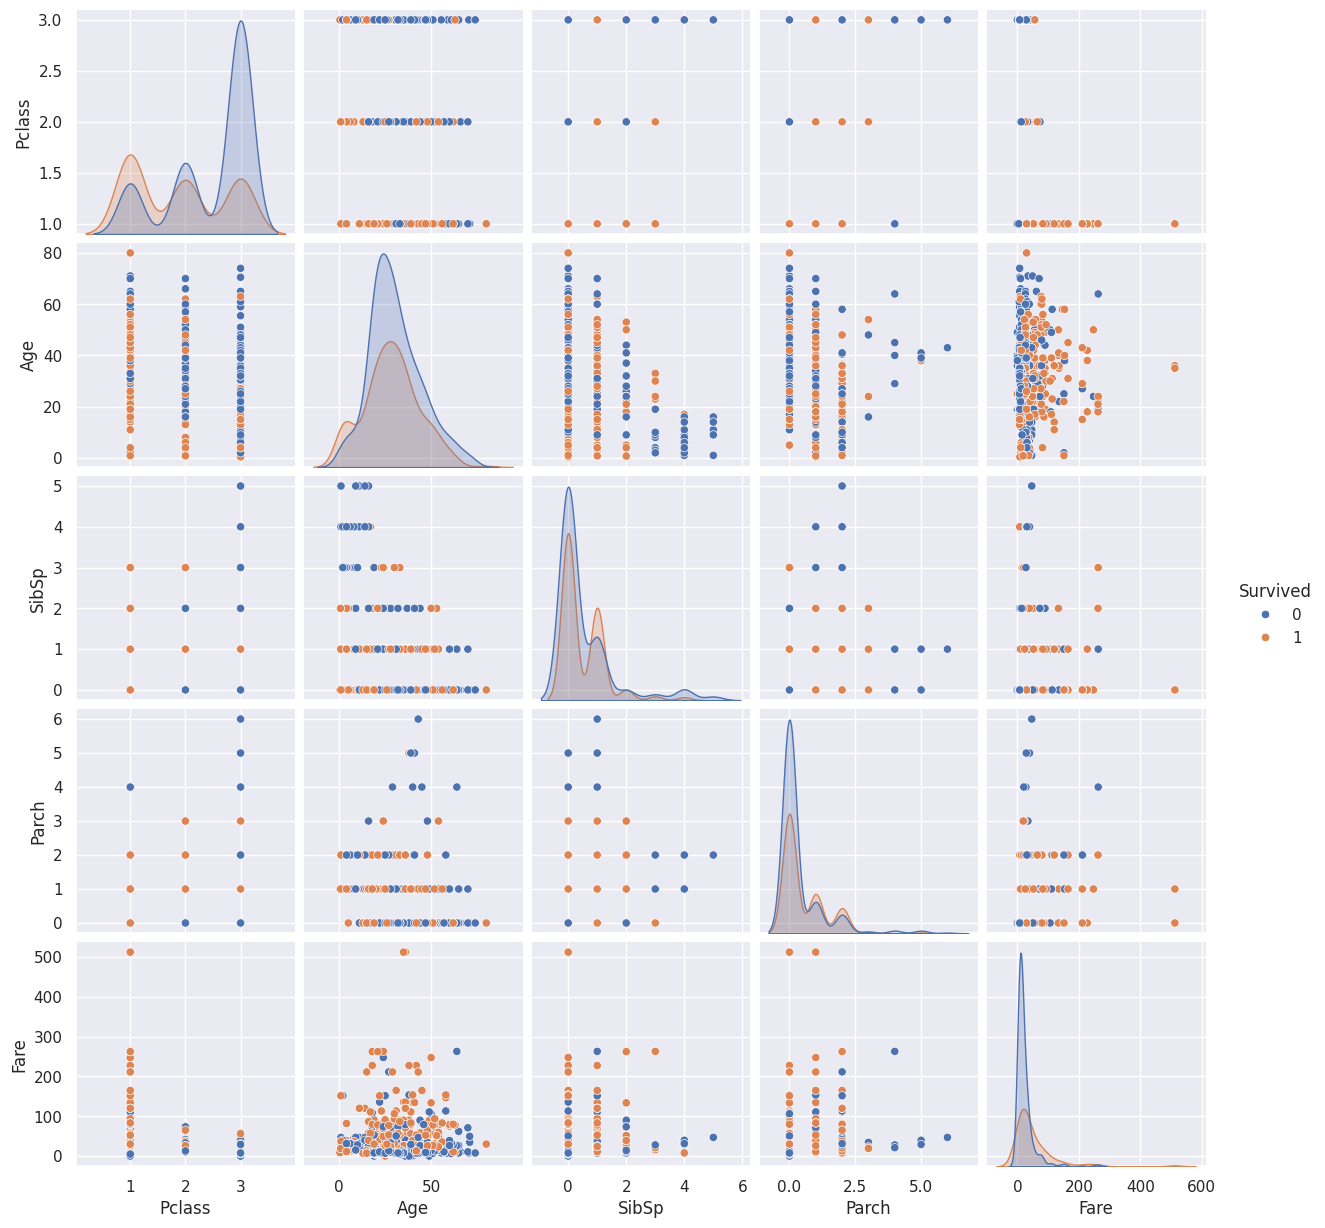

In [33]:
pairplot_data = df[
    ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
].dropna()

sns.pairplot(
    pairplot_data,
    hue="Survived"
)

plt.show()

### Observation
The pairplot provides multiple views of relationships between numerical variables. It helps identify patterns, clusters and possible relationships between passenger characteristics and survival.

In [34]:
survival_rate = df["Survived"].mean() * 100

print(f"Overall survival rate: {survival_rate:.2f}%")

Overall survival rate: 38.38%


# Final Findings

The Exploratory Data Analysis of the Titanic dataset revealed several important patterns:

1. The dataset contains 891 passenger records.
2. Passenger age has a wide distribution, with most passengers being young or middle-aged.
3. Fare contains some high-value outliers.
4. Gender shows a noticeable relationship with survival, with female passengers having a higher survival proportion.
5. Passenger class is also related to survival, with higher-class passengers generally having better survival outcomes.
6. The correlation heatmap helps identify relationships between numerical variables.
7. The pairplot provides a visual overview of relationships among multiple numerical variables.
8. EDA helped identify patterns, relationships, distributions and anomalies in the Titanic dataset.